Files already downloaded and verified
Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9259666..2.0708537].


torch.Size([32, 32, 3])
8
ship


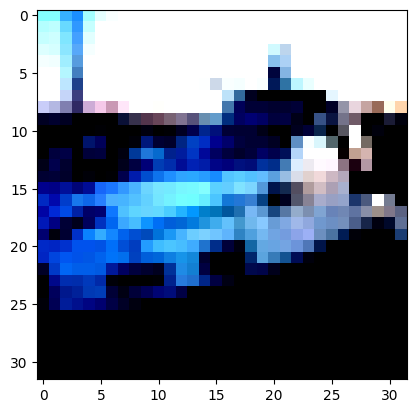

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 0 → airplane
# 1 → automobile
# 2 → bird
# 3 → cat
# 4 → deer
# 5 → dog
# 6 → frog
# 7 → horse
# 8 → ship
# 9 → truck
# print(train_data.classes[label])

mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


train_data=datasets.CIFAR10(root="./cifar_data",train=True,download=True,transform=train_transforms)
test_data=datasets.CIFAR10(root="./cifar_data",train=False,download=True,transform=test_transforms)

train_size=int(0.8*len(train_data))
val_size=len(train_data)-train_size

train_dataset,val_dataset=random_split(train_data,[train_size,val_size])


# inportant here you have to change the tranformation from train to test for valuation data
val_dataset.dataset.transform =test_transforms


train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=64,shuffle=False)
test_loader=DataLoader(test_data,batch_size=64,shuffle=False)


image,label = test_data[2]
img = image.permute(1, 2, 0)
print(img.shape)
print(label)
print(train_data.classes[label])
plt.imshow(img)



In [2]:
# class for the model
class cifar10(nn.Module):
    def __init__(self):
        super().__init__()
        self.features=nn.Sequential(
            # block 1
            nn.Conv2d(3,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # block 2
            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # block3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifiers=nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,10)
        )

    def forward(self,x):
        x=self.features(x)
        x=self.classifiers(x)
        return x



# example to check te model
model=cifar10()
input=torch.rand(1,3,32,32)
out=model(input)
print(out.shape)

print(torch.cuda.is_available())
# print(torch.cuda.get_device_name(0))





torch.Size([1, 10])
True


In [3]:
# training loop
train_losses = []
val_accuracies = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = cifar10().to(device)

optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
loss_fn=nn.CrossEntropyLoss()

epochs=40
for epoch in range(epochs):
    model.train()
    # train
    adding_loss=0
    for image , label in (train_loader):
        image = image.to(device)
        label = label.to(device)
        output=model(image)
        loss=loss_fn(output,label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        adding_loss += loss.item()

    print()
    average_loss=adding_loss/len(train_loader)
    # print(f"this is the average loss ")
    if (epoch+1) %5==0:
        print(f"the average loss of train data epoch {epoch +1} is {average_loss} ")



    # valuation
    model.eval()
    val_total=0
    val_correct=0
    with torch.no_grad():
        for image , label in val_loader:
            image = image.to(device)
            label = label.to(device)
            output=model(image)
            _,prediction=torch.max(output,1)
            val_total +=label.size(0)
            val_correct += (prediction==label).sum().item()

        val_accuracy=100*val_correct/val_total
        # print("this is the valuation calulation")
        if (epoch+1) %5==0:
            print(f"{val_correct} are correct out of {val_total} and the valution accuracy of epoch {epoch +1} is {val_accuracy}")
    # for the graph we are appending this value
    train_losses.append(average_loss)
    val_accuracies.append(val_accuracy)


 # test
test_total=0
test_correct=0
with torch.no_grad():
        for image , label in test_loader:
            image = image.to(device)
            label = label.to(device)
            output=model(image)
            _,prediction=torch.max(output,1)
            test_total +=label.size(0)
            test_correct += (prediction==label).sum().item()

        test_accuracy=100*test_correct/test_total
        print("this is the test calulation")

        print(f"{test_correct} are correct out of {test_total} and the test accuracy is {test_accuracy}")








the average loss of train data epoch 5 is 0.6410204534530639 
7973 are correct out of 10000 and the valution accuracy of epoch 5 is 79.73





the average loss of train data epoch 10 is 0.3535831200003624 
8188 are correct out of 10000 and the valution accuracy of epoch 10 is 81.88





the average loss of train data epoch 15 is 0.18551124228537083 
8215 are correct out of 10000 and the valution accuracy of epoch 15 is 82.15





the average loss of train data epoch 20 is 0.11757859992980957 
8292 are correct out of 10000 and the valution accuracy of epoch 20 is 82.92





the average loss of train data epoch 25 is 0.08597583852186799 
8325 are correct out of 10000 and the valution accuracy of epoch 25 is 83.25





the average loss of train data epoch 30 is 0.0714832486346364 
8369 are correct out of 10000 and the valution accuracy of epoch 30 is 83.69





the average loss of train data epoch 35 is 0.05730255727507174 
8241 are correct out of 10000 and the valution accuracy of e

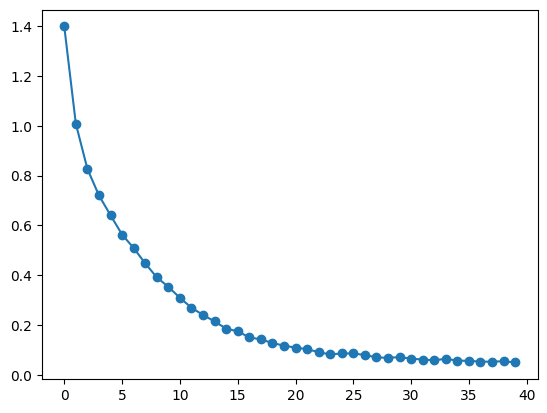

In [4]:
# graph of the loss
plt.plot(train_losses, marker="o")

In [5]:
# now we are trying to change the paramere and all that tu find what change  and will compare this both as we can see what change the accure and how much

# training loop
train_losses = []
val_accuracies = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = cifar10().to(device)

optimizer=torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-4)  #we also add this weight_decay=1e-4


'''# first we change the lr after ever 20 epoch '''
scheduler=torch.optim.lr_scheduler.StepLR(optimizer,step_size=20,gamma=0.1)


loss_fn=nn.CrossEntropyLoss()

epochs=40
for epoch in range(epochs):
    model.train()
    # train
    adding_loss=0
    for image , label in (train_loader):
        image = image.to(device)
        label = label.to(device)
        output=model(image)
        loss=loss_fn(output,label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        adding_loss += loss.item()

    print()
    average_loss=adding_loss/len(train_loader)

    # print(f"this is the average loss ")
    if (epoch+1) %5==0:
        print(f"the average loss of train data epoch {epoch +1} is {average_loss} ")




    # valuation
    model.eval()
    val_total=0
    val_correct=0
    with torch.no_grad():
        for image , label in val_loader:
            image = image.to(device)
            label = label.to(device)
            output=model(image)
            _,prediction=torch.max(output,1)
            val_total +=label.size(0)
            val_correct += (prediction==label).sum().item()

        val_accuracy=100*val_correct/val_total
        # print("this is the valuation calulation")
        if (epoch+1) %5==0:
            print(f"{val_correct} are correct out of {val_total} and the valution accuracy of epoch {epoch +1} is {val_accuracy}")
    # for the graph we are appending this value
    train_losses.append(average_loss)
    val_accuracies.append(val_accuracy)
    print()


    '''this is the function that chnge the lr'''
    scheduler.step()

 # test
test_total=0
test_correct=0
with torch.no_grad():
        for image , label in test_loader:
            image = image.to(device)
            label = label.to(device)
            output=model(image)
            _,prediction=torch.max(output,1)
            test_total +=label.size(0)
            test_correct += (prediction==label).sum().item()

        test_accuracy=100*test_correct/test_total
        print("this is the test calulation")

        print(f"{test_correct} are correct out of {test_total} and the test accuracy is {test_accuracy}")













the average loss of train data epoch 5 is 0.6486762592792511 
7649 are correct out of 10000 and the valution accuracy of epoch 5 is 76.49










the average loss of train data epoch 10 is 0.3745183894276619 
8108 are correct out of 10000 and the valution accuracy of epoch 10 is 81.08










the average loss of train data epoch 15 is 0.21475653896927835 
8282 are correct out of 10000 and the valution accuracy of epoch 15 is 82.82










the average loss of train data epoch 20 is 0.1337158910214901 
8304 are correct out of 10000 and the valution accuracy of epoch 20 is 83.04










the average loss of train data epoch 25 is 0.021311634076200427 
8511 are correct out of 10000 and the valution accuracy of epoch 25 is 85.11










the average loss of train data epoch 30 is 0.011269193263631313 
8538 are correct out of 10000 and the valution accuracy of epoch 30 is 85.38










the average loss of train data epoch 35 is 0.008043664857395924 
8548 are correct out of

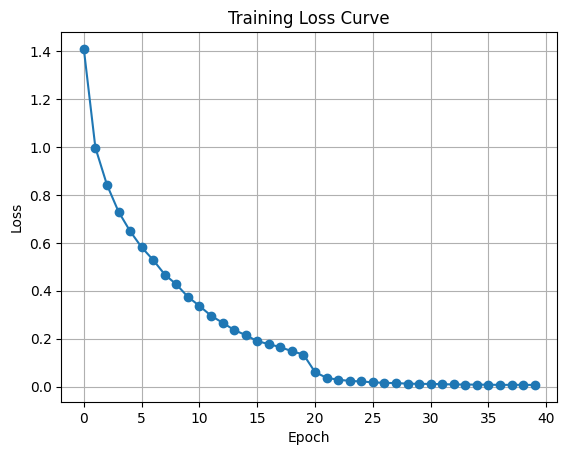

In [6]:

plt.plot(train_losses,marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()


[[842   7  34  18  17   4   7  11  40  20]
 [  9 903   1   4   1   2   5   3  17  55]
 [ 33   0 777  35  50  50  32  17   5   1]
 [ 12   2  42 686  35 156  33  20   7   7]
 [  7   0  38  28 851  26  23  25   2   0]
 [  3   0  27  86  26 823  11  23   1   0]
 [  2   1  29  33  23  15 887   3   5   2]
 [  8   0  16  16  33  50   3 870   2   2]
 [ 28  10   4   5   2   3   5   2 924  17]
 [  9  30   3   8   1   0   3   7  23 916]]


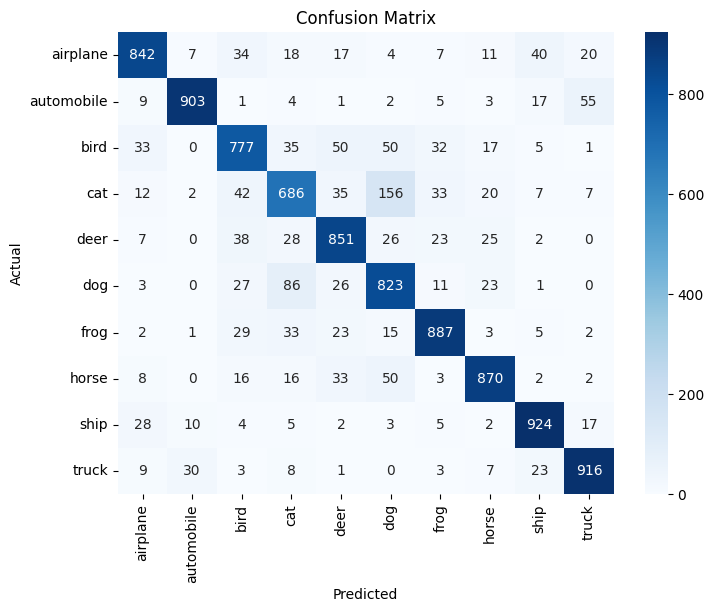

In [7]:
# confusion matrix

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
print(cm)

class_names = train_data.classes  # ['airplane', 'automobile', ...]
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [8]:
# save the parameters

torch.save(model.state_dict(), "mnist_cnn.pth")
print("Model saved successfully.")
state = torch.load("mnist_cnn.pth")
print(state.keys())

Model saved successfully.
odict_keys(['features.0.weight', 'features.0.bias', 'features.1.weight', 'features.1.bias', 'features.1.running_mean', 'features.1.running_var', 'features.1.num_batches_tracked', 'features.3.weight', 'features.3.bias', 'features.4.weight', 'features.4.bias', 'features.4.running_mean', 'features.4.running_var', 'features.4.num_batches_tracked', 'features.7.weight', 'features.7.bias', 'features.8.weight', 'features.8.bias', 'features.8.running_mean', 'features.8.running_var', 'features.8.num_batches_tracked', 'features.10.weight', 'features.10.bias', 'features.11.weight', 'features.11.bias', 'features.11.running_mean', 'features.11.running_var', 'features.11.num_batches_tracked', 'features.14.weight', 'features.14.bias', 'features.15.weight', 'features.15.bias', 'features.15.running_mean', 'features.15.running_var', 'features.15.num_batches_tracked', 'features.17.weight', 'features.17.bias', 'features.18.weight', 'features.18.bias', 'features.18.running_mean', '

C:\Users\suren\AppData\Local\Temp\ipykernel_15352\3055481566.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load("mnist_cnn.pth")


In [ ]:
class_correct = cm.diagonal()
class_total = cm.sum(axis=1)
class_accuracy = class_correct / class_total

for i, acc in enumerate(class_accuracy):
    print()
    print(f"{class_names[i]}: {acc*100:.2f}%")

    

airplane: 84.20%
automobile: 90.30%
bird: 77.70%
cat: 68.60%
deer: 85.10%
dog: 82.30%
frog: 88.70%
horse: 87.00%
ship: 92.40%
truck: 91.60%
